# 📊 Sales Data Analysis Dashboard v1.0

## Business Problem

Retail businesses generate thousands of sales transactions every day. Without proper analysis, it is difficult to identify high-performing products, profitable regions, customer purchasing patterns, and operational inefficiencies.

Data-driven decision making helps businesses improve profitability, optimize inventory, and understand customer behavior.

---

## Project Objective

The objective of this project is to analyze historical sales data using Python and identify meaningful business insights through data cleaning, exploratory data analysis (EDA), and visualization.

---

## Project Goals

- Analyze overall sales performance
- Evaluate profit trends
- Identify top-performing products and categories
- Understand customer segments
- Analyze regional performance
- Study the impact of discounts on profitability
- Generate actionable business recommendations

## Importing Required Libraries

Before starting the analysis, we import the required Python libraries.

- **Pandas** → Data manipulation
- **NumPy** → Numerical computations
- **Matplotlib** → Basic visualizations
- **Seaborn** → Advanced statistical visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Better visualization style
plt.style.use("ggplot")

## Loading the Dataset

The dataset is stored in Excel format (.xls). We load it into a Pandas DataFrame for further analysis.

In [5]:
df = pd.read_excel("../data/SampleSuperstore.xls")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Understanding the Dataset

Before cleaning or analyzing the data, it is important to understand its structure, size, columns, and data types.

In [6]:
# Shape of dataset
df.shape

(9994, 21)

In [7]:
# Column names
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [8]:
# Basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [9]:
# First five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
# Last five rows
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,2017-05-04,2017-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [11]:
# Missing values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [12]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

In [13]:
# Statistical summary
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [14]:
# Summary including categorical columns
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,NaN,NaN,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,NaN,NaN,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,NaN,NaN,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,NaN,NaN,NaN,NaN,NaN,NaN,...,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
min,1.000000,NaN,2014-01-03 00:00:00,2014-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,2015-05-23 00:00:00,2015-05-27 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,2016-06-26 00:00:00,2016-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,2017-05-14 00:00:00,2017-05-18 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000
max,9994.000000,NaN,2017-12-30 00:00:00,2018-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,99301.000000,NaN,NaN,NaN,NaN,NaN,22638.480000,14.000000,0.800000,8399.976000


### Key Findings

- No missing values were found.
- No duplicate rows were identified.
- Dataset contains 9,994 records and 21 columns.
- Order Date and Ship Date are stored as datetime objects.
- Dataset is ready for further cleaning and exploratory analysis.

## Data Quality Check

The dataset was examined for:

- Missing values
- Duplicate records
- Incorrect data types

Result:
- No missing values found.
- No duplicate records found.
- All data types were appropriate.

Since the dataset was already clean, no additional data cleaning was required.

# Feature Engineering

## Objective

Feature engineering is the process of creating new variables from existing data to make analysis more meaningful.

In this project, we will create date-related features from the **Order Date** column. These features will help us analyze sales trends across years, months, quarters, and weekdays.

In [16]:
# Create new features from Order Date

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month Name"] = df["Order Date"].dt.month_name()
df["Order Quarter"] = "Q" + df["Order Date"].dt.quarter.astype(str)
df["Order Day"] = df["Order Date"].dt.day
df["Day of Week"] = df["Order Date"].dt.day_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Order Quarter,Order Day,Day of Week
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,2016,11,November,Q4,8,Tuesday
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,2016,11,November,Q4,8,Tuesday
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,2016,6,June,Q2,12,Sunday
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,2015,10,October,Q4,11,Sunday
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,2015,10,October,Q4,11,Sunday


In [17]:
df[[
    "Order Date",
    "Order Year",
    "Order Month",
    "Order Month Name",
    "Order Quarter",
    "Order Day",
    "Day of Week"
]].head()

,Order Date,Order Year,Order Month,Order Month Name,Order Quarter,Order Day,Day of Week
0,2016-11-08,2016,11,November,Q4,8,Tuesday
1,2016-11-08,2016,11,November,Q4,8,Tuesday
2,2016-06-12,2016,6,June,Q2,12,Sunday
3,2015-10-11,2015,10,October,Q4,11,Sunday
4,2015-10-11,2015,10,October,Q4,11,Sunday


## Feature Engineering Summary

The following new features were created:

- **Order Year** – Enables year-wise sales analysis.
- **Order Month** – Useful for chronological sorting.
- **Order Month Name** – Improves readability in charts.
- **Order Quarter** – Supports quarterly performance analysis.
- **Order Day** – Allows day-level analysis if required.
- **Day of Week** – Helps identify sales patterns across weekdays.

These engineered features will be used throughout the exploratory data analysis (EDA) phase.

# Exploratory Data Analysis (EDA)

## Business Question 1

What is the overall business performance?

Before analyzing individual regions, categories, or customers, it is important to understand the company's overall performance through key business metrics.

In [18]:
# Key Performance Indicators (KPIs)

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
average_sales = df["Sales"].mean()
average_profit = df["Profit"].mean()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_customers}")
print(f"Average Sales per Transaction: ${average_sales:,.2f}")
print(f"Average Profit per Transaction: ${average_profit:,.2f}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5009
Total Customers: 793
Average Sales per Transaction: $229.86
Average Profit per Transaction: $28.66


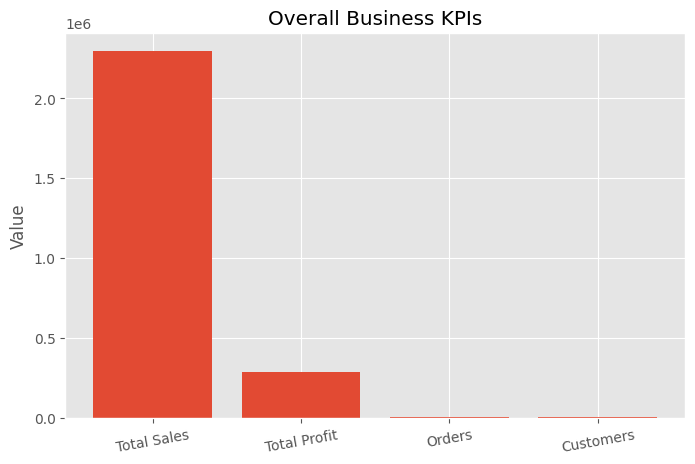

In [19]:
kpis = {
    "Total Sales": total_sales,
    "Total Profit": total_profit,
    "Orders": total_orders,
    "Customers": total_customers
}

plt.figure(figsize=(8,5))
plt.bar(kpis.keys(), kpis.values())
plt.title("Overall Business KPIs")
plt.ylabel("Value")
plt.xticks(rotation=10)
plt.show()

### Business Interpretation

The KPI summary provides a high-level overview of the company's performance.

It highlights the overall sales generated, total profit earned, number of unique orders processed, and the customer base served. These metrics establish a baseline for deeper analysis in the following sections.

### Key Insight

The business has processed a large number of orders across multiple customers, generating substantial sales and profit. Further analysis is required to determine which regions, products, and customer segments contribute the most to this performance.

## Business Question 2

### How have sales changed over time?

Understanding sales trends over time helps businesses identify growth patterns, seasonal demand, and periods of high or low performance.

In [20]:
monthly_sales = (
    df.groupby(["Order Year", "Order Month", "Order Month Name"])["Sales"]
      .sum()
      .reset_index()
)

# Sort months correctly
monthly_sales = monthly_sales.sort_values(
    by=["Order Year", "Order Month"]
)

monthly_sales.head()

,Order Year,Order Month,Order Month Name,Sales
0,2014,1,January,14236.895
1,2014,2,February,4519.892
2,2014,3,March,55691.009
3,2014,4,April,28295.345
4,2014,5,May,23648.287


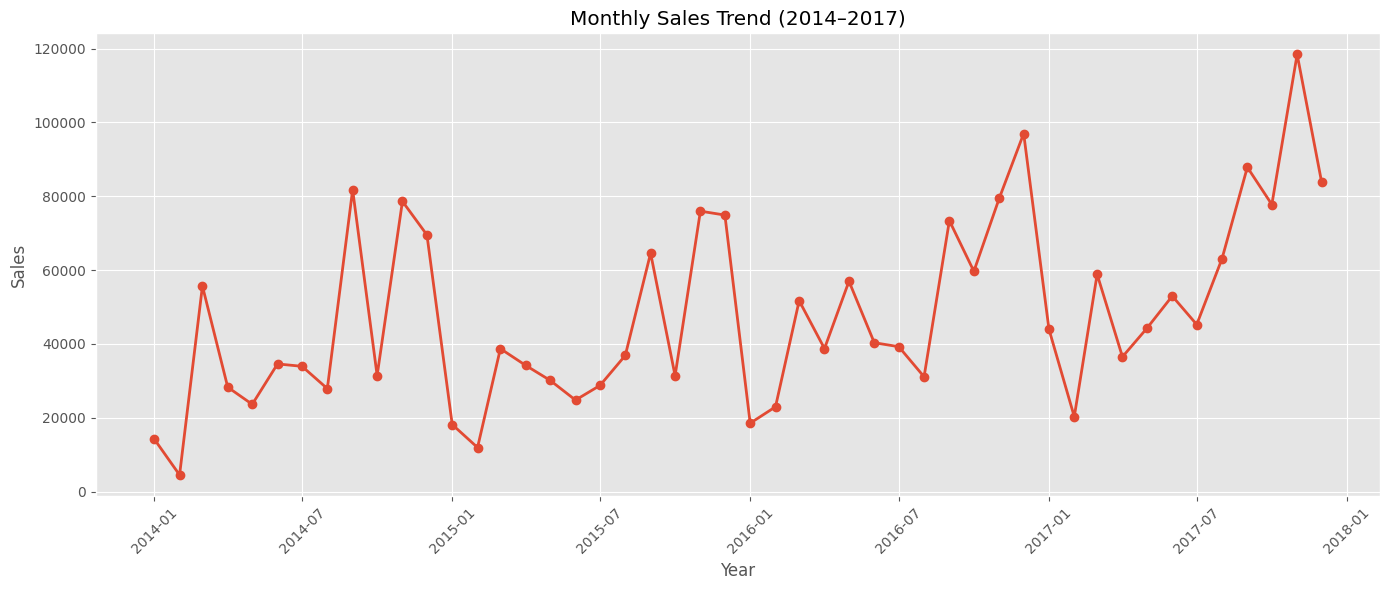

In [61]:
monthly_sales["Year-Month"] = pd.to_datetime(
    monthly_sales["Order Year"].astype(str)
    + "-"
    + monthly_sales["Order Month"].astype(str)
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Year-Month"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend (2014–2017)")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../images/monthly_sales_trend.png", dpi=300, bbox_inches="tight")

plt.show()

### Business Interpretation

The monthly sales trend shows noticeable fluctuations throughout the four-year period (2014–2017). While sales vary from month to month, the overall trend indicates business growth over time, with 2017 recording the strongest monthly sales figures.

Higher sales are observed towards the end of several years, suggesting a possible seasonal increase in customer demand during the final quarter.

### Key Insights

- Sales generally increased over the four-year period, with 2017 being the strongest performing year.
- November 2017 recorded the highest monthly sales during the observed period.
- February 2014 had one of the lowest monthly sales values.
- Several year-end months (especially November and December) consistently show higher sales, indicating a potential seasonal sales pattern.

## Business Question 3

### Which region contributes the most to sales and profit?

Regional analysis helps identify high-performing markets and areas where business performance can be improved.

In [23]:
region_analysis = (
    df.groupby("Region")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

region_analysis

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


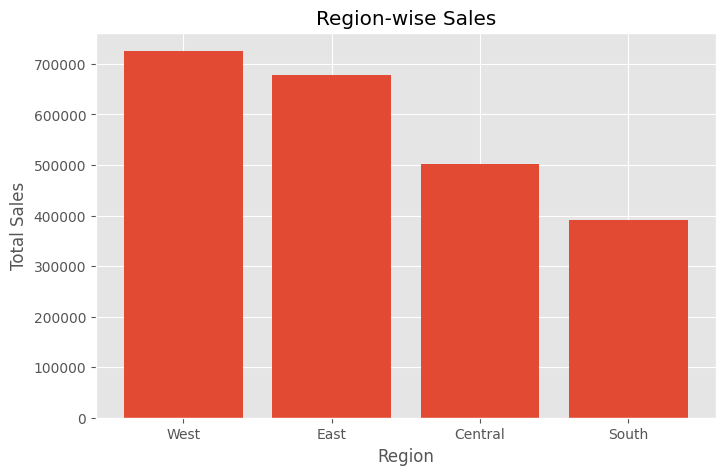

In [65]:
plt.figure(figsize=(8,5))

plt.bar(
    region_analysis.index,
    region_analysis["Sales"]
)

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.savefig("../images/region_sales.png", dpi=300, bbox_inches="tight")

plt.show()

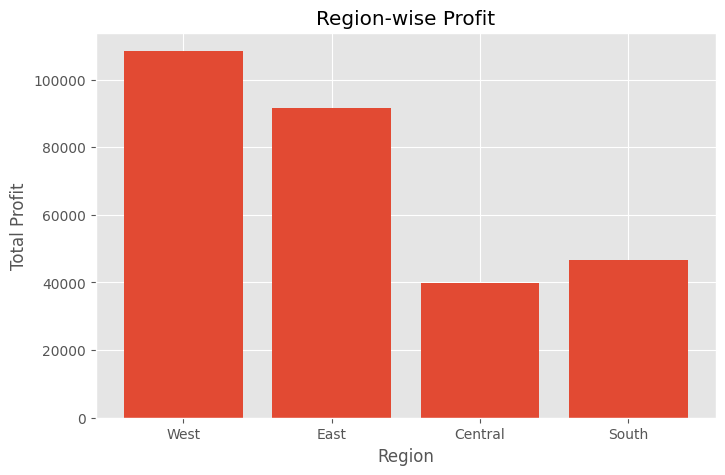

In [66]:
plt.figure(figsize=(8,5))

plt.bar(
    region_analysis.index,
    region_analysis["Profit"]
)

plt.title("Region-wise Profit")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.savefig("../images/region_profit.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- The **West** region recorded the highest total sales.
- The **East** region ranked second in both sales and profit.
- The **Central** region generated higher sales than the South region but reported the lowest overall profit.
- Although the **South** region had the lowest sales, it achieved higher profit than the Central region.

### Business Interpretation

The West region is the strongest-performing market, leading in both sales and profitability, making it a key contributor to the company's overall performance.

The Central region shows comparatively weaker profitability despite generating moderate sales, indicating possible issues such as higher discounts, increased operational costs, or a less profitable product mix.

The South region demonstrates relatively better profitability compared to its sales volume, suggesting efficient business performance in that region.

### Business Recommendations

- Continue investing in the West region to maintain its strong market position.
- Investigate the Central region to identify factors reducing profitability, such as excessive discounts or low-margin products.
- Explore opportunities to increase sales in the South region while maintaining its healthy profit performance.
- Study successful sales strategies used in the West region and replicate them in lower-performing regions where appropriate.

## Business Question 4

### Which product categories and sub-categories contribute the most to sales and profit?

Understanding category and sub-category performance helps businesses identify their best-performing products and areas that require improvement.

In [26]:
category_analysis = (
    df.groupby("Category")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

category_analysis

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


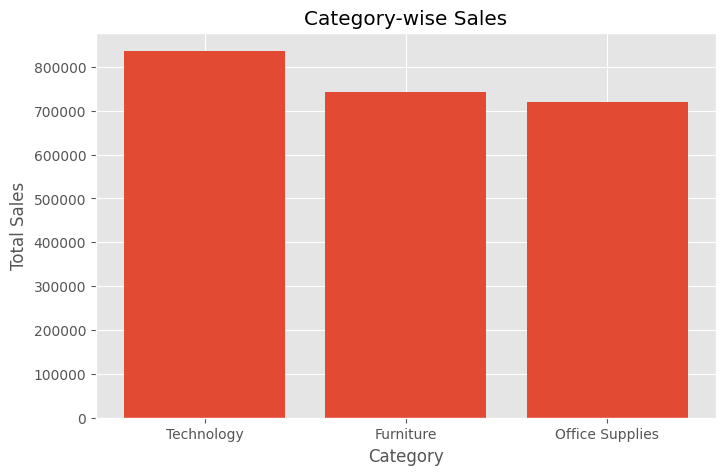

In [68]:
plt.figure(figsize=(8,5))

plt.bar(
    category_analysis.index,
    category_analysis["Sales"]
)

plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.savefig("../images/category_sales.png", dpi=300, bbox_inches="tight")

plt.show()

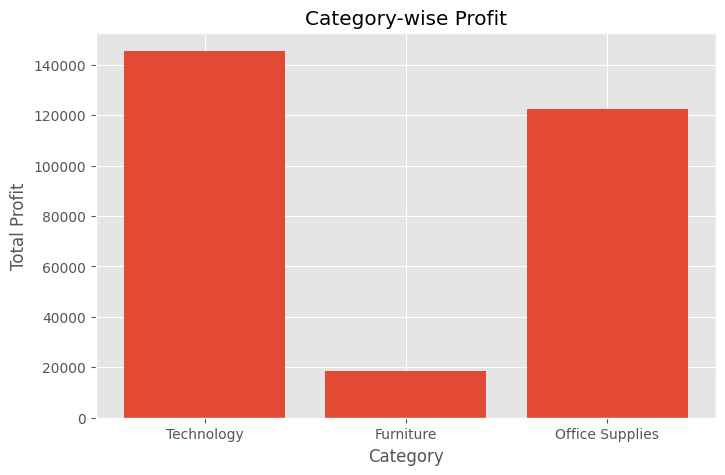

In [67]:
plt.figure(figsize=(8,5))

plt.bar(
    category_analysis.index,
    category_analysis["Profit"]
)

plt.title("Category-wise Profit")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.savefig("../images/category_profit.png", dpi=300, bbox_inches="tight")

plt.show()

In [29]:
sub_category_analysis = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

sub_category_analysis

,Sales,Profit
Sub-Category,,
Phones,330007.0540,44515.7306
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Tables,206965.5320,-17725.4811
Binders,203412.7330,30221.7633
Machines,189238.6310,3384.7569
Accessories,167380.3180,41936.6357
Copiers,149528.0300,55617.8249
Bookcases,114879.9963,-3472.5560


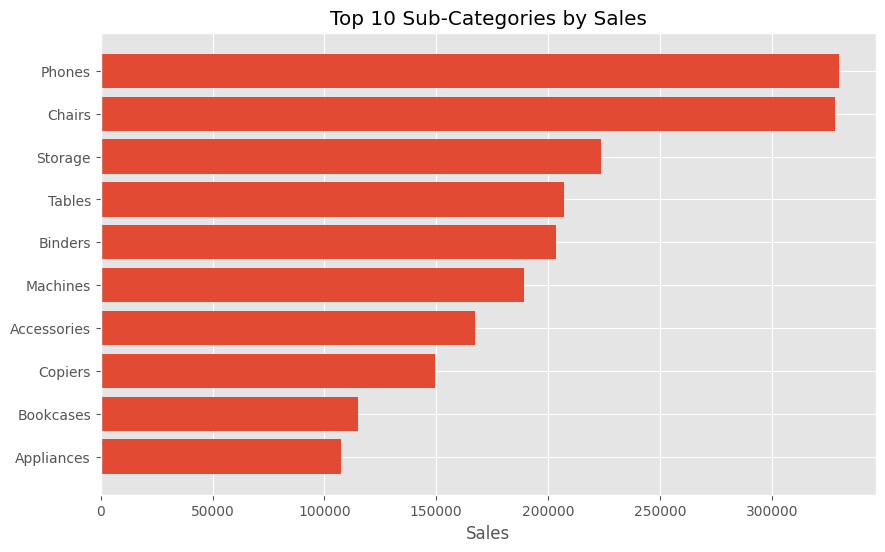

In [70]:
top_sales = sub_category_analysis.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_sales.index,
    top_sales["Sales"]
)

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sales")

plt.gca().invert_yaxis()

plt.savefig("../images/subcategory_sales.png", dpi=300, bbox_inches="tight")

plt.show()

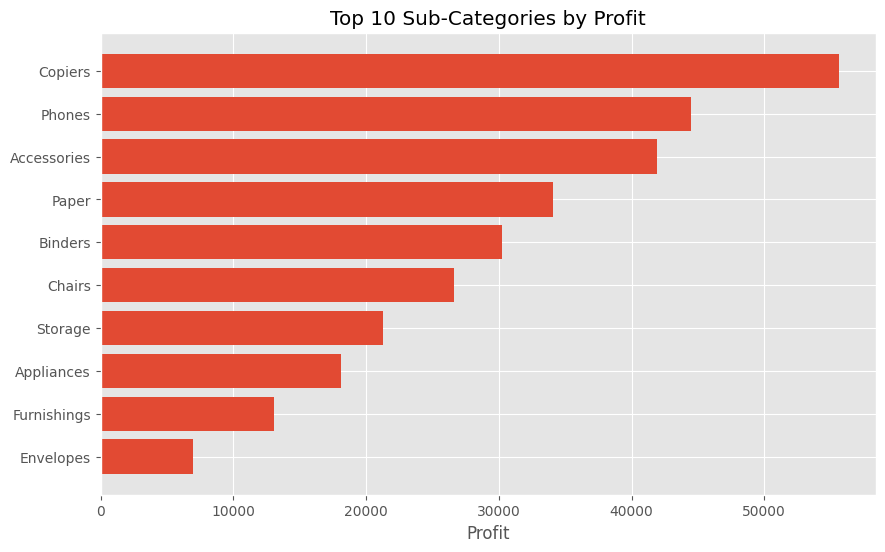

In [71]:
top_profit = (
    sub_category_analysis
    .sort_values(by="Profit", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_profit.index,
    top_profit["Profit"]
)

plt.title("Top 10 Sub-Categories by Profit")
plt.xlabel("Profit")

plt.gca().invert_yaxis()

plt.savefig("../images/subcategory_profit.png", dpi=300, bbox_inches="tight")

plt.show()

In [32]:
loss_subcategories = (
    sub_category_analysis
    .sort_values(by="Profit")
)

loss_subcategories.head(10)

,Sales,Profit
Sub-Category,,
Tables,206965.5320,-17725.4811
Bookcases,114879.9963,-3472.5560
Supplies,46673.5380,-1189.0995
Fasteners,3024.2800,949.5182
Machines,189238.6310,3384.7569
Labels,12486.3120,5546.2540
Art,27118.7920,6527.7870
Envelopes,16476.4020,6964.1767
Furnishings,91705.1640,13059.1436


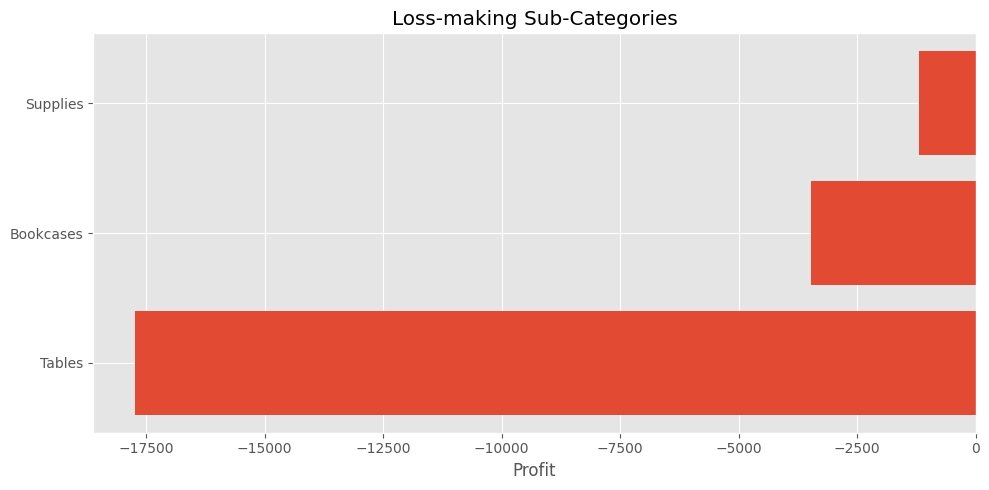

In [34]:
loss_products = (
    sub_category_analysis[sub_category_analysis["Profit"] < 0]
    .sort_values(by="Profit")
)

plt.figure(figsize=(10,5))

plt.barh(
    loss_products.index,
    loss_products["Profit"]
)

plt.title("Loss-making Sub-Categories")
plt.xlabel("Profit")

plt.tight_layout()
plt.show()

### Observation

- Technology generated the highest total sales among all product categories.
- Furniture ranked second in sales but recorded significantly lower profit compared to the other categories.
- Office Supplies generated slightly lower sales than Furniture but achieved substantially higher profit.
- Phones was the highest-selling sub-category.
- Copiers generated the highest profit among all sub-categories despite not being the highest-selling product.
- Tables recorded the largest financial loss among all sub-categories.
- Bookcases also resulted in a negative profit, although the losses were considerably smaller than Tables.

### Business Interpretation

Technology is the strongest-performing category, contributing significantly to both revenue and profitability. This indicates strong customer demand and healthy profit margins.

Furniture requires closer attention. Although it generates high sales, its profit contribution is disproportionately low, suggesting reduced margins due to factors such as discounts, pricing strategy, or product costs.

The Copiers sub-category demonstrates that high profitability is not always linked to the highest sales volume, highlighting the importance of evaluating profit alongside revenue.

The consistent losses in the Tables and Bookcases sub-categories indicate potential pricing, discounting, or cost-related issues that should be investigated further.

### Business Recommendations

- Continue investing in the Technology category to sustain its strong sales and profitability.
- Investigate the Furniture category to improve profit margins through pricing, supplier negotiations, or discount optimization.
- Promote high-margin products such as Copiers to increase overall profitability.
- Review pricing and discount strategies for Tables and Bookcases, as these products are generating financial losses.
- Focus future marketing campaigns on products that contribute both high sales and strong profits rather than sales volume alone.

### Business Impact

This analysis enables management to identify profitable product categories, prioritize high-performing products, and take corrective actions for loss-making sub-categories. These insights can support pricing decisions, inventory planning, and product portfolio optimization.

## Business Question 5

### Does offering higher discounts reduce profitability?

Discounts can increase sales, but excessive discounts may reduce or even eliminate profits.

This analysis examines the relationship between discount percentage and profit to understand whether higher discounts negatively impact business performance.

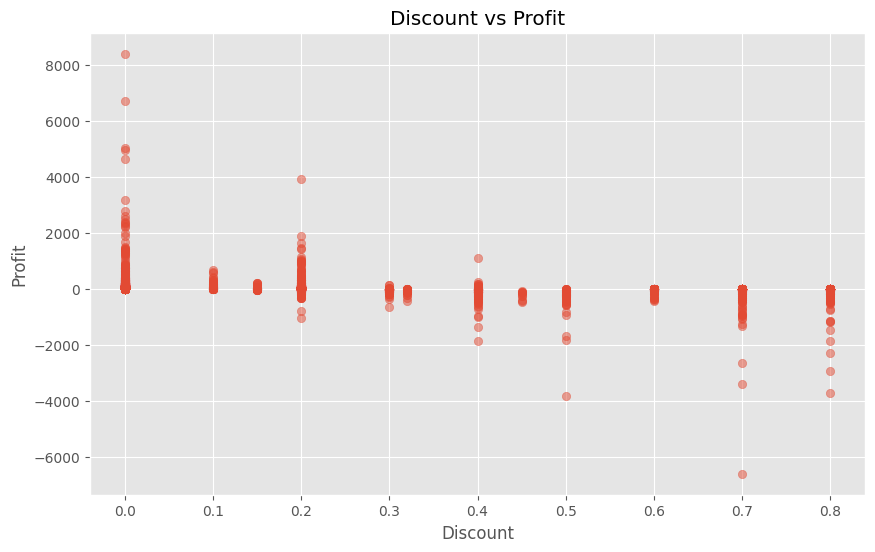

In [72]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.savefig("../images/discount_vs_profit.png", dpi=300, bbox_inches="tight")

plt.show()

In [36]:
correlation = df["Discount"].corr(df["Profit"])

print(f"Correlation between Discount and Profit: {correlation:.2f}")

Correlation between Discount and Profit: -0.22


In [37]:
discount_analysis = (
    df.groupby("Discount")["Profit"]
      .mean()
      .reset_index()
)

discount_analysis

,Discount,Profit
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


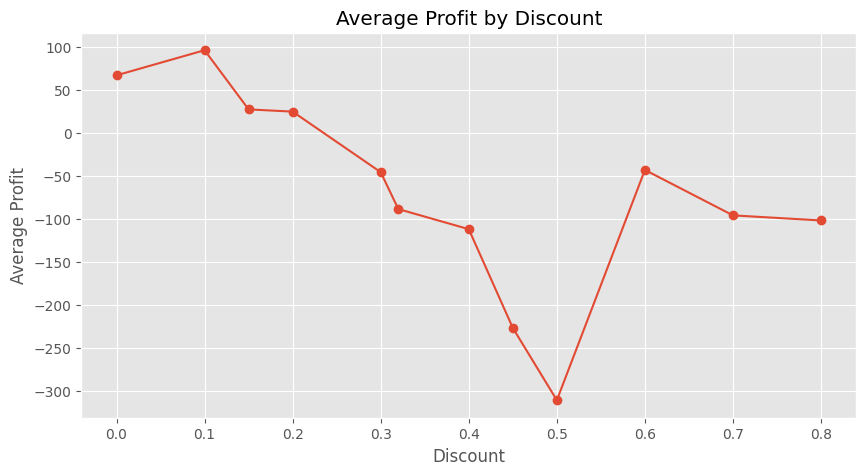

In [38]:
plt.figure(figsize=(10,5))

plt.plot(
    discount_analysis["Discount"],
    discount_analysis["Profit"],
    marker="o"
)

plt.title("Average Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.grid(True)

plt.show()

In [39]:
discount_orders = (
    df.groupby("Discount")
      .size()
      .reset_index(name="Number of Orders")
)

discount_orders

,Discount,Number of Orders
0,0.00,4798
1,0.10,94
2,0.15,52
3,0.20,3657
4,0.30,227
5,0.32,27
6,0.40,206
7,0.45,11
8,0.50,66
9,0.60,138


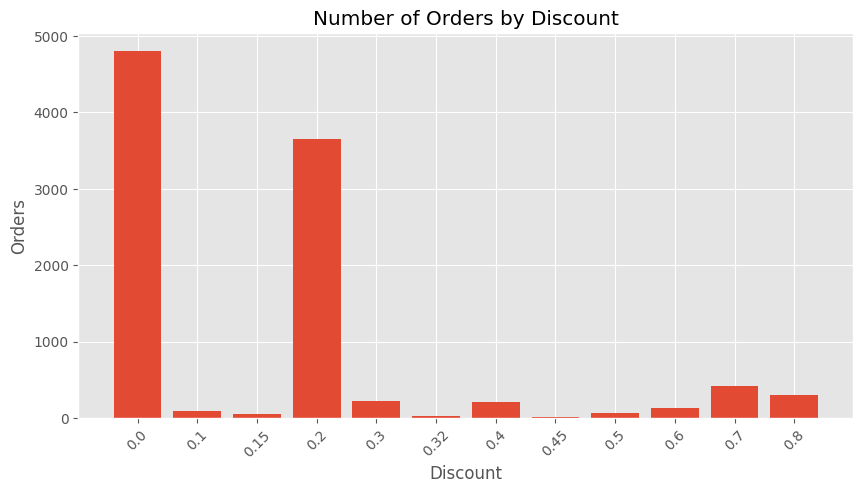

In [40]:
plt.figure(figsize=(10,5))

plt.bar(
    discount_orders["Discount"].astype(str),
    discount_orders["Number of Orders"]
)

plt.title("Number of Orders by Discount")
plt.xlabel("Discount")
plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

### Observation

- The correlation between Discount and Profit is **-0.22**, indicating a weak negative relationship.
- As discount levels increase, the average profit generally decreases.
- Orders with **0% and 10% discounts** have the highest average profits.
- At around **50% discount**, the average profit reaches its lowest point.
- The majority of orders were placed with **0% discount**, followed by **20% discount**.
- High discount levels (70%–80%) are relatively less frequent but are often associated with negative profits.

### Business Interpretation

The analysis indicates that increasing discounts does not necessarily improve business profitability. While discounts may encourage purchases, higher discount levels are generally associated with lower average profits.

The weak negative correlation (-0.22) suggests that discount is one of several factors influencing profit, but excessive discounting appears to increase the likelihood of loss-making transactions.

### Business Recommendations

- Review pricing strategies for products receiving high discounts.
- Avoid offering deep discounts (especially 50% and above) unless they are supported by strong business objectives such as inventory clearance.
- Identify products that remain profitable even after discounts and prioritize promotional campaigns around them.
- Monitor the profitability of discounted sales regularly to ensure that increased sales volume does not come at the expense of overall business performance.

### Business Impact

This analysis helps management balance sales growth and profitability. By optimizing discount strategies, the company can improve profit margins while continuing to attract customers through targeted promotions.

## Business Question 6

### Which customer segment contributes the most to sales and profit?

Different customer segments contribute differently to business growth. Analyzing their sales and profitability helps identify the most valuable customer groups and supports targeted marketing strategies.

In [42]:
segment_analysis = (
    df.groupby("Segment")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

segment_analysis

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


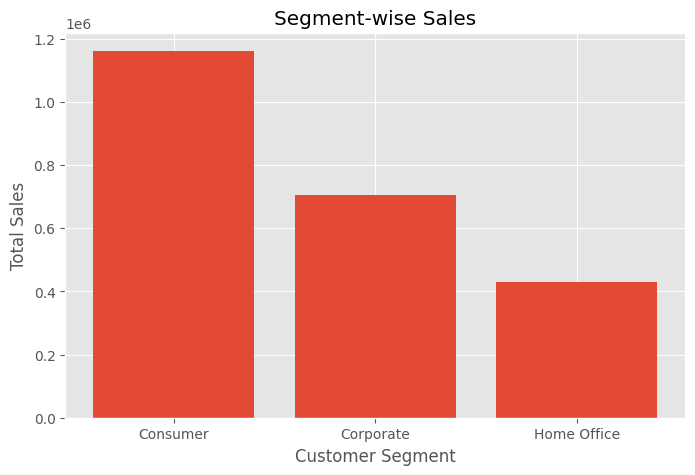

In [43]:
plt.figure(figsize=(8,5))

plt.bar(
    segment_analysis.index,
    segment_analysis["Sales"]
)

plt.title("Segment-wise Sales")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.show()

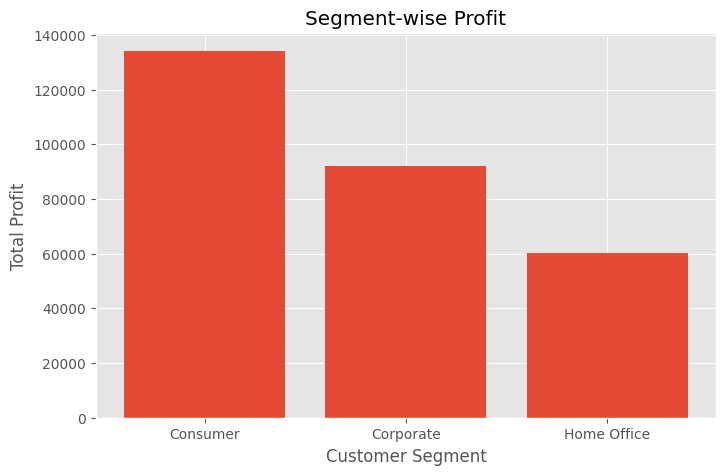

In [44]:
plt.figure(figsize=(8,5))

plt.bar(
    segment_analysis.index,
    segment_analysis["Profit"]
)

plt.title("Segment-wise Profit")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")

plt.show()

In [45]:
segment_analysis["Profit Margin (%)"] = (
    segment_analysis["Profit"] /
    segment_analysis["Sales"]
) * 100

segment_analysis

,Sales,Profit,Profit Margin (%)
Segment,,,
Consumer,1.161401e+06,134119.2092,11.548050
Corporate,7.061464e+05,91979.1340,13.025506
Home Office,4.296531e+05,60298.6785,14.034269


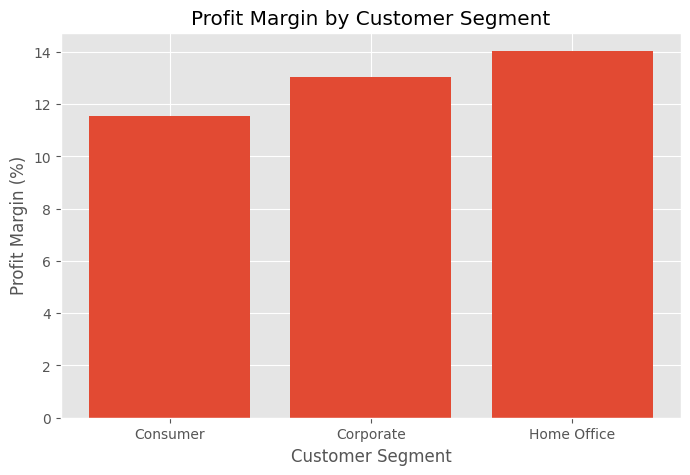

In [46]:
plt.figure(figsize=(8,5))

plt.bar(
    segment_analysis.index,
    segment_analysis["Profit Margin (%)"]
)

plt.title("Profit Margin by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Profit Margin (%)")

plt.show()

### Observation

- The Consumer segment generated the highest total sales.
- The Consumer segment also recorded the highest total profit.
- The Corporate segment ranked second in both sales and profit.
- The Home Office segment contributed the lowest sales and total profit.
- Despite having the lowest sales, the Home Office segment achieved the highest profit margin (approximately 14.03%).
- The Consumer segment generated the highest revenue but had the lowest profit margin (approximately 11.55%).

### Business Interpretation

The Consumer segment is the primary revenue driver for the business, making it the most important customer segment in terms of sales volume and total profit.

However, the Home Office segment demonstrates the highest profitability relative to its sales, indicating that it is a high-margin customer segment.

This suggests that while Consumer customers generate volume, Home Office customers contribute more efficiently to profitability.

### Business Recommendations

- Continue focusing on the Consumer segment to sustain overall revenue growth.
- Explore opportunities to expand the Home Office customer base, as it delivers the highest profit margin.
- Develop targeted marketing campaigns for Corporate customers to increase both sales and profitability.
- Analyze purchasing behavior across segments to identify products with the highest profit margins and promote them accordingly.

### Business Impact

Customer segment analysis enables the business to prioritize marketing investments, improve customer targeting, and allocate resources towards segments that maximize both revenue and profitability.

## Business Question 7

### Which states contribute the most to sales and profit?

State-wise analysis helps identify high-performing markets, underperforming regions, and potential expansion opportunities.

In [47]:
state_analysis = (
    df.groupby("State")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

state_analysis.head()

,Sales,Profit
State,,
California,457687.6315,76381.3871
New York,310876.2710,74038.5486
Texas,170188.0458,-25729.3563
Washington,138641.2700,33402.6517
Pennsylvania,116511.9140,-15559.9603


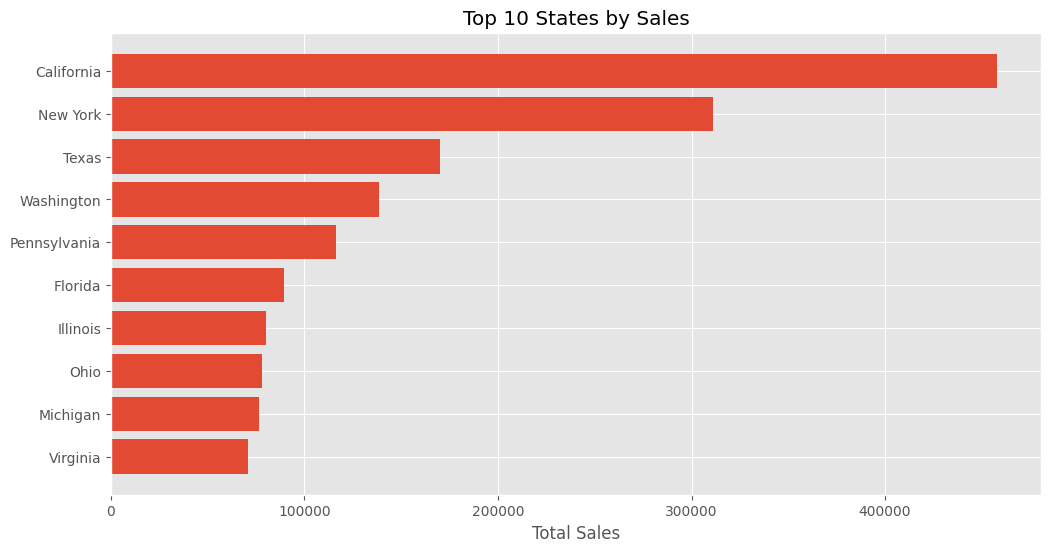

In [73]:
top_sales_states = state_analysis.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_sales_states.index,
    top_sales_states["Sales"]
)

plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")

plt.gca().invert_yaxis()

plt.savefig("../images/top_states_sales.png", dpi=300, bbox_inches="tight")

plt.show()

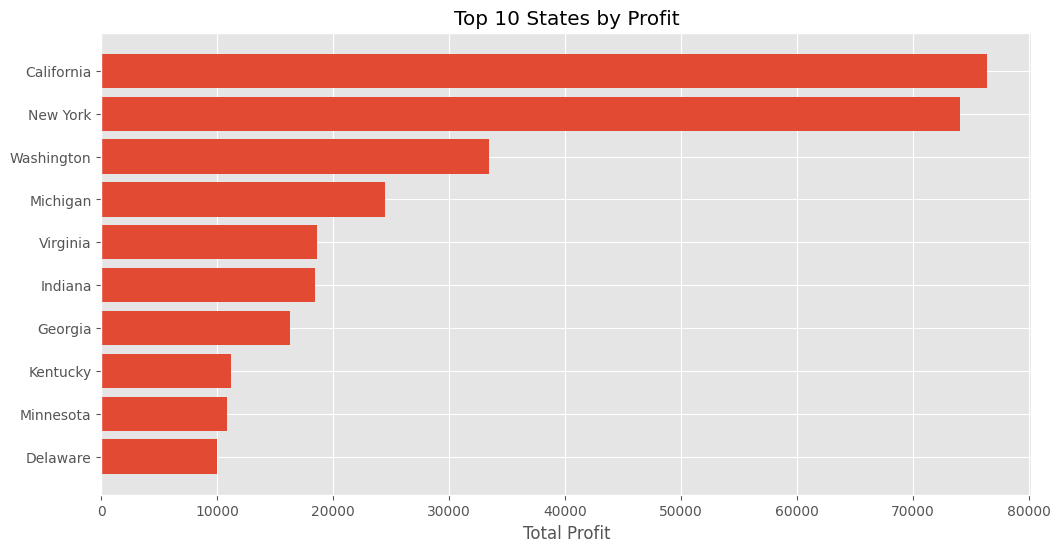

In [74]:
top_profit_states = (
    state_analysis
    .sort_values(by="Profit", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_profit_states.index,
    top_profit_states["Profit"]
)

plt.title("Top 10 States by Profit")
plt.xlabel("Total Profit")

plt.gca().invert_yaxis()

plt.savefig("../images/top_states_profit.png", dpi=300, bbox_inches="tight")

plt.show()

In [50]:
bottom_profit_states = (
    state_analysis
    .sort_values(by="Profit")
    .head(10)
)

bottom_profit_states

,Sales,Profit
State,,
Texas,170188.0458,-25729.3563
Ohio,78258.1360,-16971.3766
Pennsylvania,116511.9140,-15559.9603
Illinois,80166.1010,-12607.8870
North Carolina,55603.1640,-7490.9122
Colorado,32108.1180,-6527.8579
Tennessee,30661.8730,-5341.6936
Arizona,35282.0010,-3427.9246
Florida,89473.7080,-3399.3017


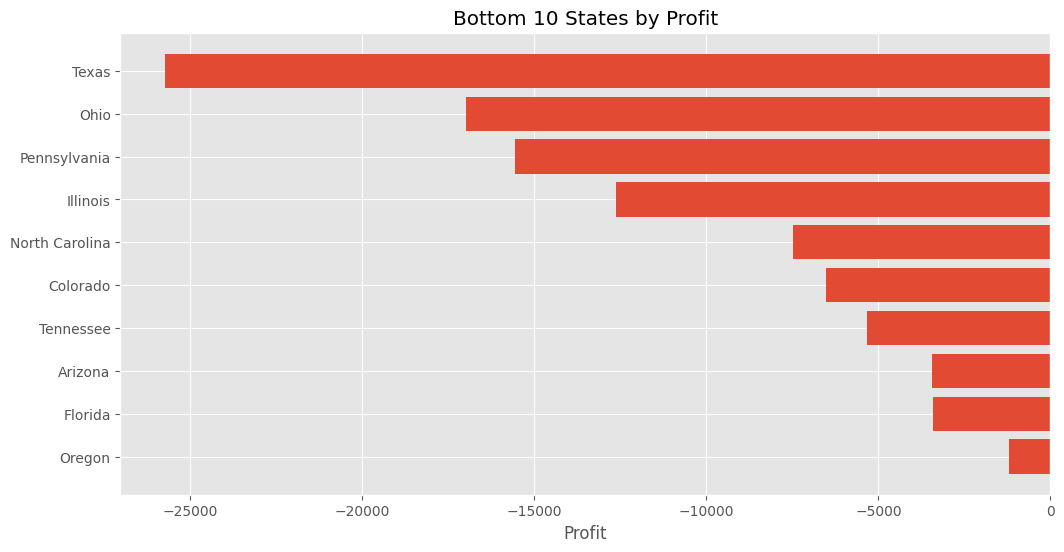

In [51]:
plt.figure(figsize=(12,6))

plt.barh(
    bottom_profit_states.index,
    bottom_profit_states["Profit"]
)

plt.title("Bottom 10 States by Profit")
plt.xlabel("Profit")

plt.gca().invert_yaxis()

plt.show()

In [52]:
state_analysis["Profit Margin (%)"] = (
    state_analysis["Profit"] /
    state_analysis["Sales"]
) * 100

state_analysis.sort_values(
    by="Profit Margin (%)",
    ascending=False
).head(10)

,Sales,Profit,Profit Margin (%)
State,,,
District of Columbia,2865.020,1059.5893,36.983662
Delaware,27451.069,9977.3748,36.346034
Minnesota,29863.150,10823.1874,36.242618
Maine,1270.530,454.4862,35.771387
Arkansas,11678.130,4008.6871,34.326447
Indiana,53555.360,18382.9363,34.325110
Georgia,49095.840,16250.0433,33.098615
Montana,5589.352,1833.3285,32.800377
Rhode Island,22627.956,7285.6293,32.197470


### Observation

- California generated the highest sales and the highest overall profit.
- New York ranked second in both sales and profitability.
- Texas was among the top three states in sales but recorded the largest overall loss.
- Washington generated strong profits despite significantly lower sales than California and New York.
- Several states, including Texas, Ohio, Pennsylvania, and Illinois, reported negative profits.
- Delaware and Minnesota achieved some of the highest profit margins despite relatively lower sales volumes.

### Business Interpretation

California and New York are the company's strongest markets, contributing significantly to both revenue and profitability.

Texas presents a major business concern. Although it generates high sales, it records the largest financial loss, suggesting pricing issues, excessive discounts, high operating costs, or an unfavorable product mix.

States such as Delaware and Minnesota demonstrate that high profitability can be achieved even without very high sales volumes, indicating efficient business performance.

### Business Recommendations

- Continue investing in California and New York to maintain market leadership.
- Perform a detailed root-cause analysis for Texas to identify factors driving significant losses.
- Review pricing, discount strategies, and product mix in loss-making states such as Texas, Ohio, and Pennsylvania.
- Study best practices from high-margin states like Delaware and Minnesota and apply similar strategies where appropriate.
- Allocate future marketing and inventory investments based on both sales and profitability rather than sales alone.

### Business Impact

State-wise analysis enables businesses to identify profitable markets, detect regions requiring corrective action, and optimize expansion strategies. These insights support better resource allocation, pricing decisions, and regional business planning.

## Business Question 8

### Who are the most valuable customers?

Identifying high-value customers helps businesses strengthen customer relationships, improve retention strategies, and focus marketing efforts on customers who contribute the most to revenue and profitability.

In [53]:
customer_analysis = (
    df.groupby("Customer Name")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

customer_analysis.head()

,Sales,Profit
Customer Name,,
Sean Miller,25043.050,-1980.7393
Tamara Chand,19052.218,8981.3239
Raymond Buch,15117.339,6976.0959
Tom Ashbrook,14595.620,4703.7883
Adrian Barton,14473.571,5444.8055


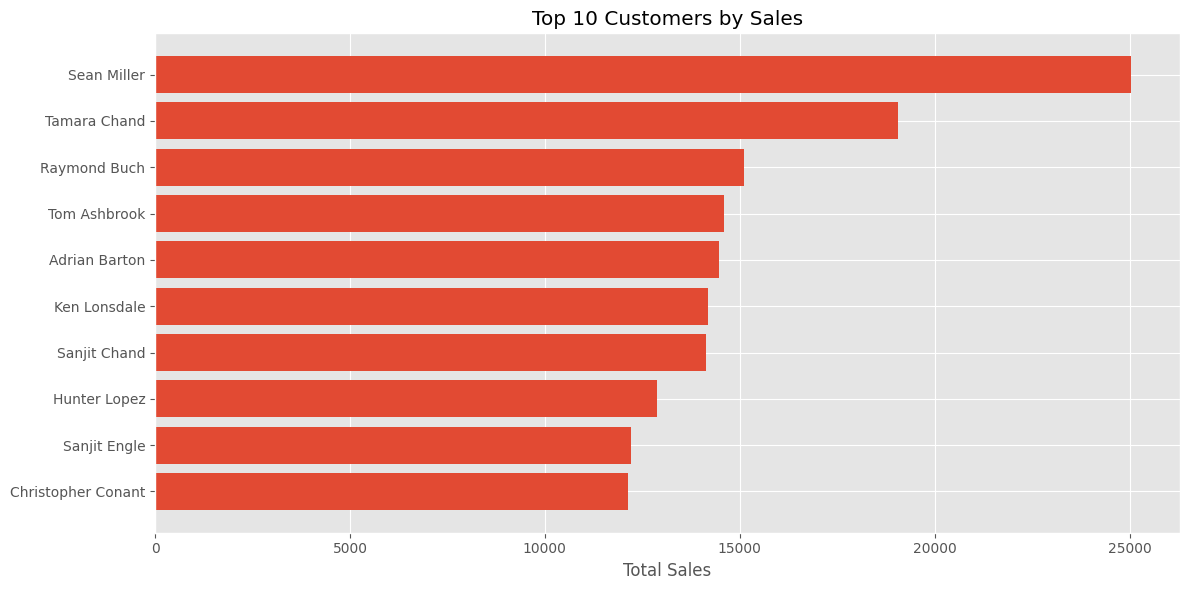

In [75]:
top_sales_customers = customer_analysis.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_sales_customers.index,
    top_sales_customers["Sales"]
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("../images/top_customers_sales.png", dpi=300, bbox_inches="tight")

plt.show()

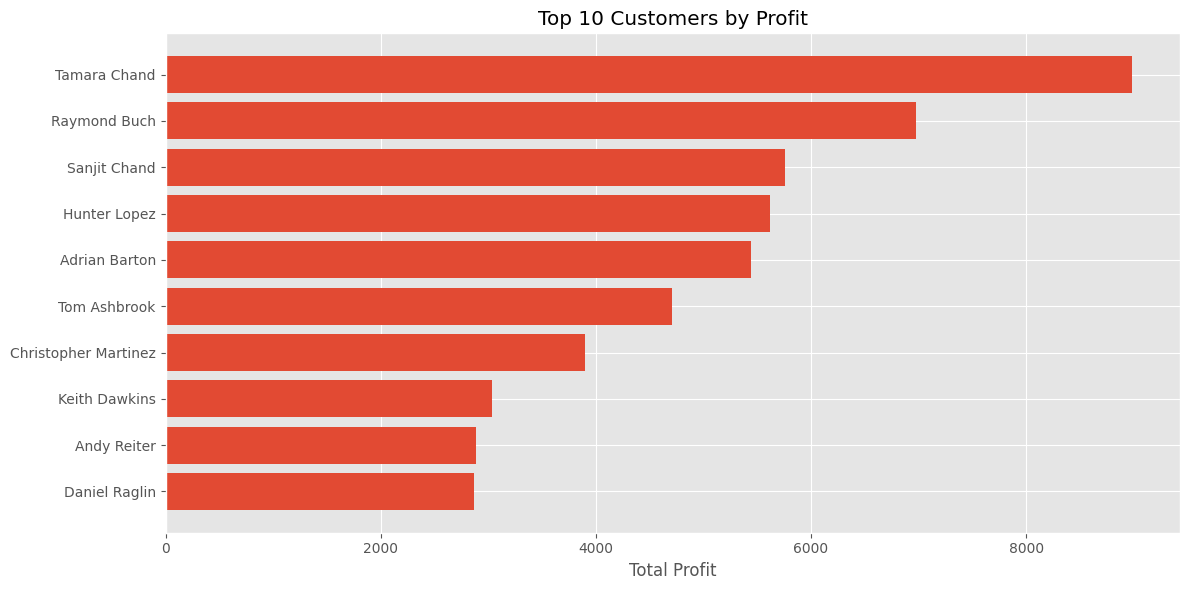

In [76]:
top_profit_customers = (
    customer_analysis
    .sort_values(by="Profit", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_profit_customers.index,
    top_profit_customers["Profit"]
)

plt.title("Top 10 Customers by Profit")
plt.xlabel("Total Profit")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("../images/top_customers_profit.png", dpi=300, bbox_inches="tight")

plt.show()

In [56]:
customer_analysis["Profit Margin (%)"] = (
    customer_analysis["Profit"] /
    customer_analysis["Sales"]
) * 100

customer_analysis.sort_values(
    by="Profit Margin (%)",
    ascending=False
).head(10)

,Sales,Profit,Profit Margin (%)
Customer Name,,,
Jenna Caffey,1058.108,502.9244,47.530536
Tamara Chand,19052.218,8981.3239,47.140569
Raymond Buch,15117.339,6976.0959,46.146322
Steven Roelle,4345.886,1990.4244,45.800198
Bobby Odegard,130.830,59.4522,45.442330
Hunter Lopez,12873.298,5622.4292,43.675127
Andy Reiter,6608.448,2884.6208,43.650503
Christopher Martinez,8954.020,3899.8904,43.554631
Ivan Gibson,744.574,320.4982,43.044506


### Observation

- Sean Miller generated the highest total sales among all customers.
- Tamara Chand ranked second in sales but generated the highest overall profit.
- Raymond Buch consistently appeared among the top customers in both sales and profit.
- Some customers with high sales were not among the highest-profit customers, indicating that higher sales do not always result in higher profitability.
- Tamara Chand and Raymond Buch achieved both high sales and excellent profit margins, making them highly valuable customers.

### Business Interpretation

The analysis shows that customer value should not be measured only by sales volume. While Sean Miller generated the highest revenue, Tamara Chand contributed the highest profit, making this customer particularly valuable to the business.

Customers who consistently generate both high sales and high profit should be prioritized for retention and personalized engagement strategies.

### Business Recommendations

- Develop customer loyalty programs for high-value customers such as Tamara Chand and Raymond Buch.
- Study purchasing patterns of highly profitable customers to identify opportunities for cross-selling and upselling.
- Focus marketing efforts on customers who contribute both high sales and strong profitability rather than revenue alone.
- Monitor customer profitability regularly to identify strategic accounts that deserve priority support.

### Business Impact

Customer-level analysis enables businesses to identify their most valuable customers, improve retention strategies, optimize marketing investments, and maximize long-term profitability.

## Business Question 9

### Which shipping mode performs the best?

Shipping mode influences delivery speed, customer satisfaction, operational cost, and profitability. This analysis evaluates the performance of each shipping mode in terms of sales and profit.

In [57]:
shipping_analysis = (
    df.groupby("Ship Mode")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

shipping_analysis

,Sales,Profit
Ship Mode,,
Standard Class,1.358216e+06,164088.7875
Second Class,4.591936e+05,57446.6354
First Class,3.514284e+05,48969.8399
Same Day,1.283631e+05,15891.7589


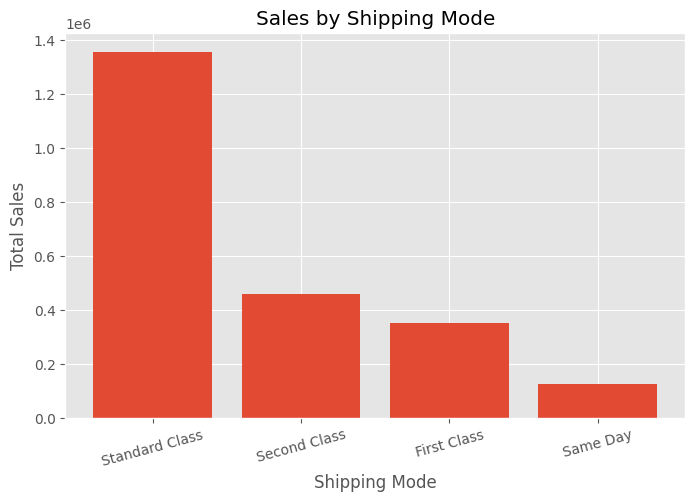

In [77]:
plt.figure(figsize=(8,5))

plt.bar(
    shipping_analysis.index,
    shipping_analysis["Sales"]
)

plt.title("Sales by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Total Sales")

plt.xticks(rotation=15)

plt.savefig("../images/shipping_sales.png", dpi=300, bbox_inches="tight")

plt.show()

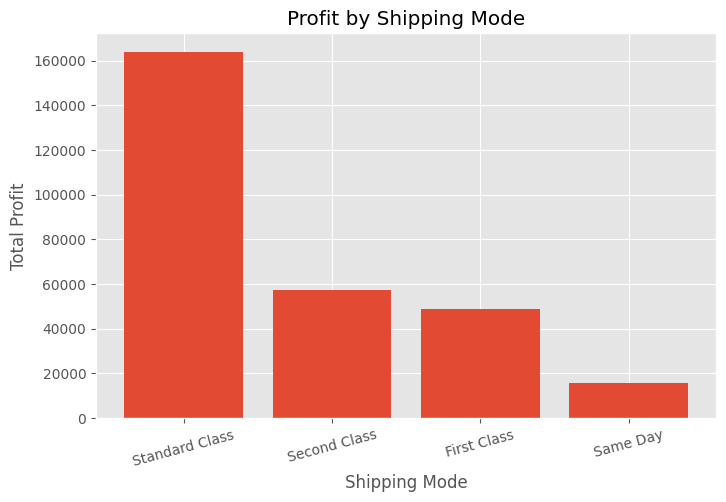

In [78]:
plt.figure(figsize=(8,5))

plt.bar(
    shipping_analysis.index,
    shipping_analysis["Profit"]
)

plt.title("Profit by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Total Profit")

plt.xticks(rotation=15)

plt.savefig("../images/shipping_profit.png", dpi=300, bbox_inches="tight")

plt.show()

In [60]:
shipping_analysis["Profit Margin (%)"] = (
    shipping_analysis["Profit"] /
    shipping_analysis["Sales"]
) * 100

shipping_analysis

,Sales,Profit,Profit Margin (%)
Ship Mode,,,
Standard Class,1.358216e+06,164088.7875,12.081202
Second Class,4.591936e+05,57446.6354,12.510331
First Class,3.514284e+05,48969.8399,13.934513
Same Day,1.283631e+05,15891.7589,12.380315


### Observation

- Standard Class generated the highest sales among all shipping modes.
- Standard Class also recorded the highest overall profit.
- First Class achieved the highest profit margin (approximately 13.93%), despite having lower total sales than Standard Class and Second Class.
- Same Day shipping contributed the lowest sales and profit.
- All shipping modes remained profitable, indicating efficient shipping operations across the business.

### Business Interpretation

Standard Class is the company's primary shipping mode, contributing the majority of both revenue and profit. This suggests that customers are comfortable choosing standard delivery while the business maintains healthy profitability.

Although First Class generates lower sales, it achieves the highest profit margin, indicating that premium shipping services can be financially efficient.

Same Day shipping contributes relatively little to overall business performance and may represent a niche service.

### Business Recommendations

- Continue optimizing Standard Class operations as it is the primary contributor to revenue and profit.
- Promote First Class shipping for customers willing to pay for faster delivery, as it delivers the highest profit margin.
- Evaluate the demand and operating costs of Same Day shipping to determine whether improvements or promotional campaigns are required.
- Monitor shipping costs regularly to ensure all delivery modes remain profitable.

### Business Impact

Shipping mode analysis helps optimize logistics strategies, improve customer satisfaction, and maximize profitability by balancing delivery speed with operational efficiency.

# Final Business Insights

Based on the complete analysis, the following key business insights were identified:

1. California generated the highest sales and overall profit, making it the strongest market for the business.

2. Texas generated high sales but recorded the largest financial loss, indicating pricing, discounting, or operational issues.

3. The West region outperformed all other regions in both sales and profitability.

4. Technology was the highest-performing product category, while Furniture generated comparatively low profit despite strong sales.

5. Tables and Bookcases consistently recorded losses, making them the weakest-performing sub-categories.

6. Higher discounts were generally associated with lower profitability. The analysis showed a negative correlation (-0.22) between discount and profit.

7. The Consumer segment generated the highest sales and total profit, whereas the Home Office segment achieved the highest profit margin.

8. Standard Class shipping contributed the highest sales and profit, while First Class achieved the highest profit margin.

9. Sean Miller generated the highest sales among customers, whereas Tamara Chand was the most profitable customer.

10. Business performance varied significantly across products, customers, states, and shipping modes, highlighting the importance of data-driven decision-making rather than relying solely on sales figures.

# Executive Summary

This project analyzes sales performance using the Sample Superstore dataset to identify key business trends and opportunities.

The analysis includes data quality assessment, feature engineering, KPI analysis, sales trends, regional performance, category analysis, customer segmentation, discount impact, state-wise performance, customer analysis, and shipping mode evaluation.

Key findings reveal that California and the West region are the strongest performers, while Texas records significant losses despite high sales. Technology is the most profitable category, whereas Furniture requires strategic improvements. Excessive discounts negatively impact profitability, and high-value customers contribute disproportionately to business success.

The insights and recommendations from this analysis can support better pricing strategies, inventory planning, regional expansion, customer retention, and overall business decision-making.

# Final Business Recommendations

Based on the complete analysis, the following recommendations are proposed to improve overall business performance:

### 1. Optimize Discount Strategy
- Avoid excessive discounts, especially on products with low profit margins.
- Review discount policies regularly to maintain a healthy balance between sales growth and profitability.

### 2. Improve Loss-Making Products
- Investigate the Tables and Bookcases sub-categories to identify pricing, supplier cost, or inventory issues.
- Consider revising pricing strategies or reducing discounts for these products.

### 3. Strengthen High-Performing Markets
- Continue investing in California, New York, and the West region, as they contribute significantly to sales and profit.
- Replicate successful strategies from these markets in other regions where feasible.

### 4. Address Underperforming States
- Perform detailed analysis for Texas and other loss-making states to identify operational inefficiencies, pricing challenges, or product mix issues.
- Implement corrective actions to improve profitability.

### 5. Focus on High-Value Customers
- Develop loyalty programs and personalized marketing campaigns for customers who consistently generate high sales and profit.
- Strengthen customer retention initiatives for key accounts.

### 6. Promote High-Margin Categories
- Increase marketing efforts for Technology products and other high-margin product lines.
- Review the product mix to maximize overall profitability.

### 7. Enhance Customer Segmentation
- Continue targeting the Consumer segment for revenue growth while expanding the Home Office segment, which demonstrates the highest profit margin.

### 8. Optimize Shipping Strategy
- Maintain efficient Standard Class operations while promoting First Class shipping for customers who value faster delivery and contribute higher profit margins.

### 9. Adopt Data-Driven Decision Making
- Regularly monitor sales, profit, discounts, customer behavior, and regional performance using dashboards to support informed business decisions.

# Conclusion

This project successfully analyzed the Sample Superstore dataset to evaluate business performance across products, customers, regions, states, shipping modes, and discount strategies.

The analysis demonstrated that sales alone do not accurately represent business success. Profitability varies across product categories, customer segments, geographical regions, and discount levels, emphasizing the importance of analyzing multiple business metrics together.

The insights generated from this project can help organizations optimize pricing strategies, improve customer retention, strengthen profitable markets, reduce losses, and make more informed business decisions.

Overall, this project demonstrates how data analytics can transform raw business data into meaningful insights that support strategic decision-making.